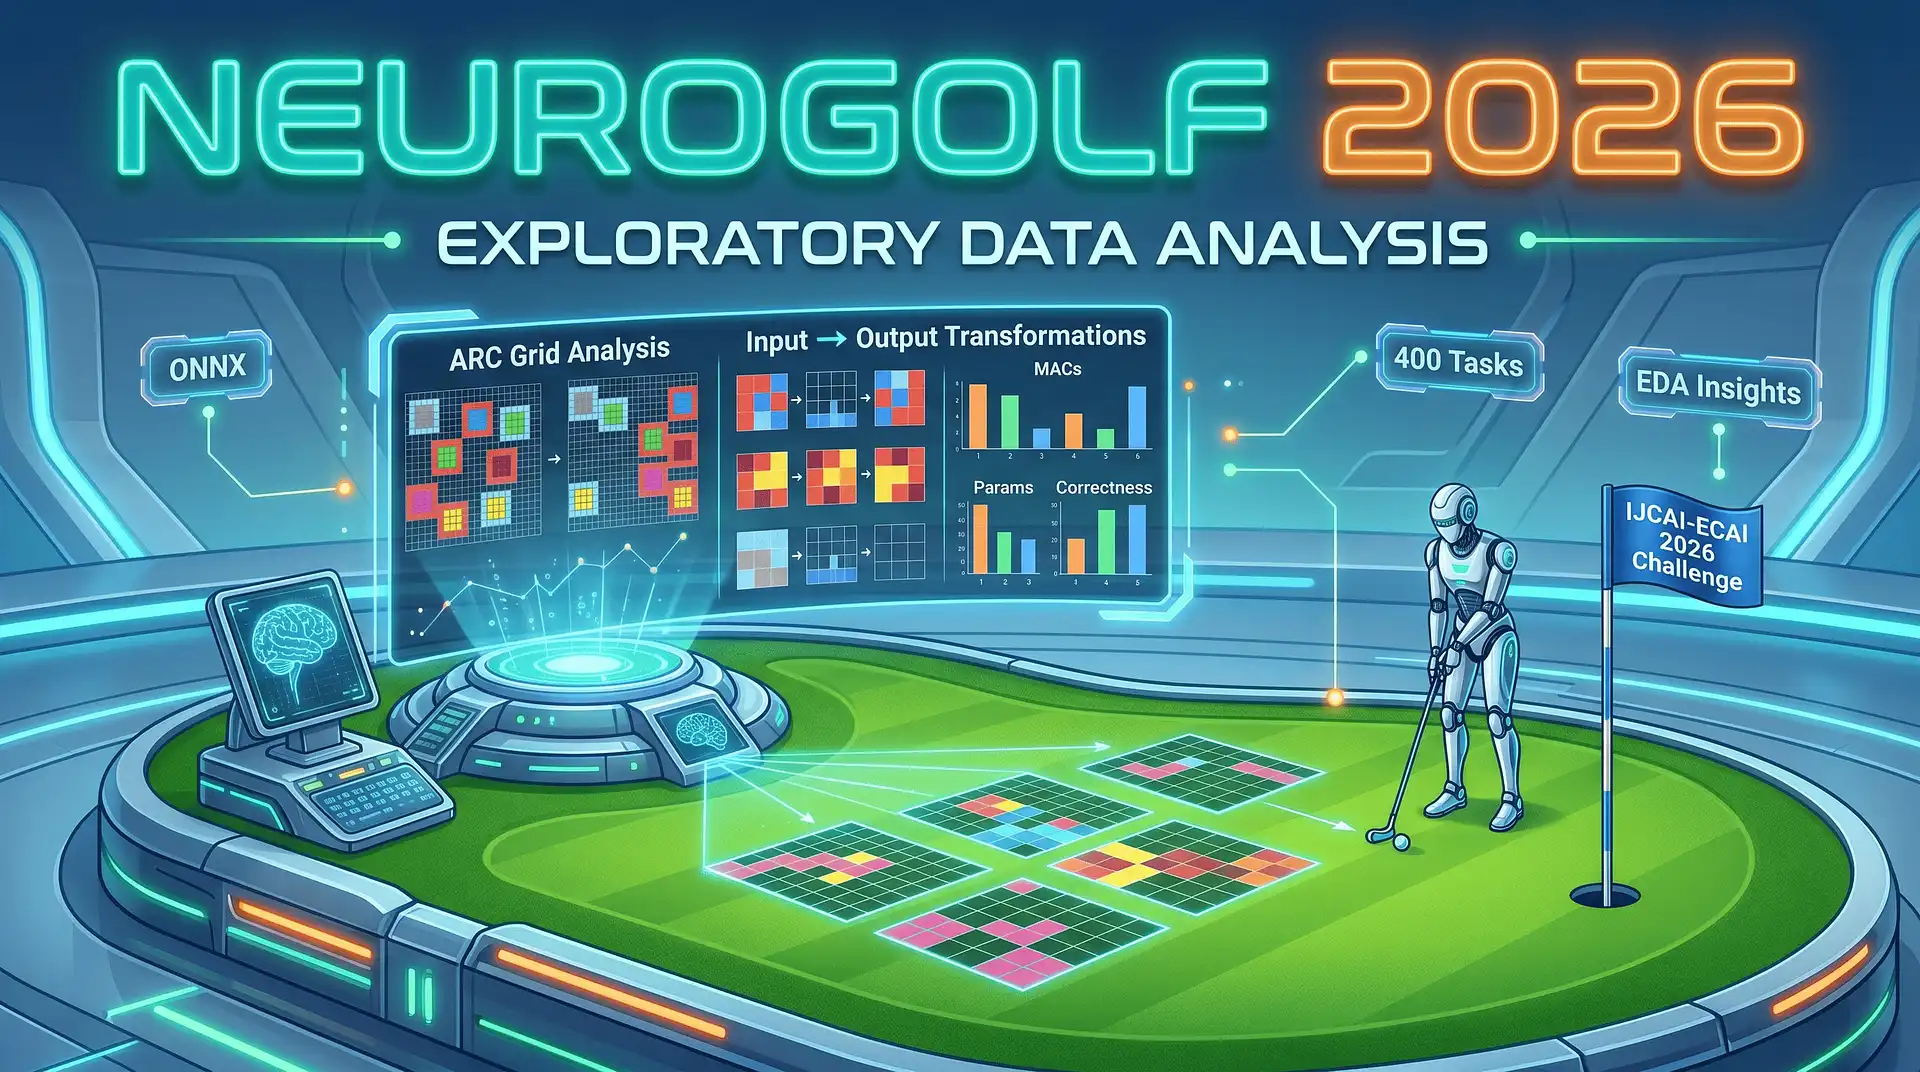

# NeuroGolf 2026 — Exploratory Data Analysis

**IJCAI-ECAI 2026 NeuroGolf Challenge**

> **Goal:** Build ONNX neural networks (one per task, up to 400) implementing ARC-AGI grid
> transformations. Scored on **correctness** (exact match across all examples) and **efficiency**
> (MACs + memory + params).

This notebook systematically analyzes all 400 tasks to uncover patterns, quantify structural
properties, and guide neural-network architecture design.

---

## Table of Contents
| # | Section | Key Insight |
|---|---------|-------------|
| 0 | Setup & Imports | 400 tasks, 101,718 total pairs |
| 1 | Dataset Overview | arc-gen dominates (100,000 pairs); a few tasks are outliers |
| 2 | Grid Size Analysis | Raw grids up to 70×75; 145/400 tasks have grids >15×15 |
| 3 | Color / Value Analysis | Most tasks use 3–5 colors; 130 tasks introduce new output colors |
| 4 | Input-Output Relationship | 133 additive, 122 mixed, 8 subtractive; zero pure-identity tasks |
| 5 | Spatial Patterns & Symmetry | Tiling (3), scaling (4), reflection (5) tasks — rare but structured |
| 6 | Cross-Example Consistency | 190/400 size-consistent, 119/400 color-consistent |
| 7 | Task Clustering | 7 clusters via PCA + k-means; 32% variance explained |
| 8 | Difficulty Estimation | Scores range 0.007–0.705; easiest tasks have 2–3 colors, small grids |
| 9 | Conv2D Feasibility | 218/400 plausibly single-Conv2D; most same-size tasks need kernel ≥ 9 |
| 10 | Sample Gallery | 20 visualizations spanning easy → hard |
| 11 | Key Findings & Recommendations | Architecture guide, task ordering, pitfalls |

---

## Section 0 — Setup & Imports

Load libraries, attempt to import the competition utility module, and read all 400 task JSON files.

> **Note:** `neurogolf_utils` requires `onnx_tool` which is not pre-installed on Kaggle.
> All EDA below uses self-contained helpers. Install it via `!pip install onnx-tool` if needed.

In [ ]:
import json, os, glob, math, warnings
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product as iterproduct

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ARC-AGI official 10-color palette
ARC_CMAP_COLORS = [
    "#000000",  # 0 black
    "#0074D9",  # 1 blue
    "#FF4136",  # 2 red
    "#2ECC40",  # 3 green
    "#FFDC00",  # 4 yellow
    "#AAAAAA",  # 5 grey
    "#F012BE",  # 6 magenta
    "#FF851B",  # 7 orange
    "#7FDBFF",  # 8 azure
    "#870C25",  # 9 maroon
]
arc_cmap = mcolors.ListedColormap(ARC_CMAP_COLORS)
arc_norm = mcolors.BoundaryNorm(np.arange(-0.5, 10.5, 1), 10)

print("Core imports loaded")

In [ ]:
# Load competition utilities (if available on Kaggle)
NEUROGOLF_UTILS_AVAILABLE = False
try:
    import importlib.util
    utils_path = "/kaggle/input/competitions/neurogolf-2026/neurogolf_utils/neurogolf_utils.py"
    if os.path.exists(utils_path):
        spec = importlib.util.spec_from_file_location("neurogolf_utils", utils_path)
        neurogolf_utils = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(neurogolf_utils)
        NEUROGOLF_UTILS_AVAILABLE = True
        print("neurogolf_utils loaded from competition data")
except Exception as e:
    print(f"neurogolf_utils not available ({e}). Using built-in helpers.")

In [ ]:
# Load all 400 task JSON files
DATA_DIR = Path("/kaggle/input/competitions/neurogolf-2026")
if not DATA_DIR.exists():
    DATA_DIR = Path("/mnt/user-data/uploads")
    print(f"Competition data dir not found. Using fallback: {DATA_DIR}")

tasks = {}
load_errors = []

for task_num in range(1, 401):
    fname = DATA_DIR / f"task{task_num:03d}.json"
    try:
        with open(fname) as f:
            tasks[task_num] = json.load(f)
    except FileNotFoundError:
        load_errors.append(task_num)
    except Exception as e:
        load_errors.append(task_num)

total_pairs = sum(
    sum(len(tasks[t].get(s, [])) for s in ["train", "test", "arc-gen"])
    for t in tasks
)
print(f"Tasks loaded: {len(tasks)} / 400")
print(f"Total pairs across all splits: {total_pairs:,}")
if load_errors:
    print(f"Missing/errored task files: {len(load_errors)}")

## Section 1 — Dataset Overview

How many examples per task per split?

- **train** and **test** come from ARC-AGI-1 (manually curated, few examples per task).
- **arc-gen** comes from ARC-GEN-100K (synthetically generated, up to 262 examples per task).
- arc-gen examples are the best proxy for the private holdout set — prioritize passing them.

Key numbers from the data: **400 tasks**, **101,718 total pairs** (1,302 train + 416 test + 100,000 arc-gen).

In [ ]:
# Count pairs per split per task
split_counts = {"train": [], "test": [], "arc-gen": []}
task_ids_ordered = sorted(tasks.keys())

for t in task_ids_ordered:
    for split in split_counts:
        split_counts[split].append(len(tasks[t].get(split, [])))

for s in split_counts:
    split_counts[s] = np.array(split_counts[s])

# Summary table
print(f"{'Split':<10} {'Min':>5} {'Max':>5} {'Mean':>8} {'Median':>8} {'Total':>8}")
print("-" * 50)
for s in ["train", "test", "arc-gen"]:
    arr = split_counts[s]
    print(f"{s:<10} {arr.min():>5} {arr.max():>5} {arr.mean():>8.1f} "
          f"{np.median(arr):>8.1f} {arr.sum():>8}")

In [ ]:
# Distribution histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, split, color in zip(axes, ["train", "test", "arc-gen"],
                              ["#0074D9", "#FF4136", "#2ECC40"]):
    data = split_counts[split]
    ax.hist(data, bins=range(0, int(data.max()) + 2), color=color,
            edgecolor="white", alpha=0.85)
    ax.set_title(f"{split} pairs per task", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of pairs")
    ax.set_ylabel("Number of tasks")
    ax.axvline(data.mean(), color="black", ls="--", lw=1, label=f"mean={data.mean():.1f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Distribution of Example Counts by Split", fontsize=14,
             fontweight="bold", y=1.03)
plt.show()

In [ ]:
# Tasks with 0 arc-gen examples
zero_arcgen = [t for t in task_ids_ordered if len(tasks[t].get("arc-gen", [])) == 0]
print(f"Tasks with 0 arc-gen examples: {len(zero_arcgen)}")
if zero_arcgen:
    print(f"  Task IDs: {zero_arcgen[:30]}{'...' if len(zero_arcgen) > 30 else ''}")

# Outliers by total example count
total_per_task = {t: sum(len(tasks[t].get(s, [])) for s in ["train","test","arc-gen"])
                  for t in tasks}
totals_arr = np.array(list(total_per_task.values()))
q1, q3 = np.percentile(totals_arr, [25, 75])
iqr = q3 - q1

outlier_low = {t: v for t, v in total_per_task.items() if v < q1 - 1.5 * iqr}
outlier_high = {t: v for t, v in total_per_task.items() if v > q3 + 1.5 * iqr}
print(f"\nOutlier tasks (IQR method):")
print(f"  Unusually FEW examples ({len(outlier_low)}): {dict(list(outlier_low.items())[:10])}")
print(f"  Unusually MANY examples ({len(outlier_high)}): {dict(list(outlier_high.items())[:10])}")

## Section 2 — Grid Size Analysis

Grid dimensions directly constrain network architecture:
- **Small grids** (≤5×5): the entire grid fits in one receptive field; small kernels suffice.
- **Medium grids** (6–15×15): standard kernels (3×3 to 15×15) are appropriate.
- **Large grids** (>15×15): need larger kernels or deeper networks with wider receptive fields.
- **Size changes** (input vs output): indicate tiling, scaling, cropping, or extraction.

> ⚠️ **Important finding:** Raw grid dimensions in the JSON can reach **70×75** — larger than the
> 30×30 limit stated in the competition description. The `convert_to_numpy` utility pads/clips to
> 30×30 tensors. Verify that any task with grids exceeding 30×30 is handled correctly in your pipeline.

In [ ]:
# Collect all grid dimensions
grid_info = []
for t in task_ids_ordered:
    for split in ["train", "test", "arc-gen"]:
        for pair in tasks[t].get(split, []):
            inp, out = pair["input"], pair["output"]
            grid_info.append({
                "task": t, "split": split,
                "in_h": len(inp), "in_w": len(inp[0]),
                "out_h": len(out), "out_w": len(out[0]),
            })

gi = {k: np.array([g[k] for g in grid_info])
      for k in ["in_h", "in_w", "out_h", "out_w", "task"]}
gi["in_area"] = gi["in_h"] * gi["in_w"]
gi["out_area"] = gi["out_h"] * gi["out_w"]

print(f"Total grids analyzed: {len(grid_info):,}")
print(f"\n{'Metric':<12} {'Min':>5} {'Max':>5} {'Mean':>7} {'Median':>7}")
print("-" * 40)
for key in ["in_h", "in_w", "out_h", "out_w", "in_area", "out_area"]:
    arr = gi[key]
    print(f"{key:<12} {arr.min():>5} {arr.max():>5} {arr.mean():>7.1f} {np.median(arr):>7.1f}")

In [ ]:
# Distribution of heights and widths
max_grid_dim = max(gi["in_h"].max(), gi["in_w"].max(), gi["out_h"].max(), gi["out_w"].max())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key, title, color in [
    (axes[0, 0], "in_h", "Input Heights", "#0074D9"),
    (axes[0, 1], "in_w", "Input Widths", "#0074D9"),
    (axes[1, 0], "out_h", "Output Heights", "#FF4136"),
    (axes[1, 1], "out_w", "Output Widths", "#FF4136"),
]:
    ax.hist(gi[key], bins=range(1, max_grid_dim + 2), color=color, edgecolor="white", alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Size (pixels)")
    ax.set_ylabel("Count")
    ax.axvline(15, color="red", ls=":", lw=1.5, label="15-pixel threshold")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.suptitle("Grid Dimension Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.show()

In [ ]:
# 2D heatmaps of (height, width) frequency
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, hkey, wkey, title in [
    (axes[0], "in_h", "in_w", "Input Grid Sizes (H x W)"),
    (axes[1], "out_h", "out_w", "Output Grid Sizes (H x W)"),
]:
    max_dim = max(gi[hkey].max(), gi[wkey].max()) + 1
    freq = np.zeros((max_dim, max_dim))
    for h, w in zip(gi[hkey], gi[wkey]):
        freq[h, w] += 1
    sns.heatmap(freq[1:max_dim, 1:max_dim], ax=ax, cmap="YlOrRd",
                xticklabels=range(1, max_dim), yticklabels=range(1, max_dim),
                cbar_kws={"label": "Frequency"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Input area vs Output area scatter
fig, ax = plt.subplots(figsize=(10, 8))
n = len(gi["in_area"])
idx = np.random.default_rng(42).choice(n, min(n, 5000), replace=False) if n > 5000 else np.arange(n)
scatter = ax.scatter(gi["in_area"][idx], gi["out_area"][idx],
                     c=gi["task"][idx], cmap="tab20", alpha=0.4, s=12, edgecolors="none")
ax.plot([0, gi["in_area"].max()], [0, gi["in_area"].max()], "k--", lw=1, alpha=0.5, label="input = output area")
ax.set_xlabel("Input Area (pixels)", fontsize=12)
ax.set_ylabel("Output Area (pixels)", fontsize=12)
ax.set_title("Input Area vs Output Area", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Size ratio analysis per task
task_size_info = {}
for t in task_ids_ordered:
    ratios = []
    for split in ["train", "test", "arc-gen"]:
        for pair in tasks[t].get(split, []):
            in_area = len(pair["input"]) * len(pair["input"][0])
            out_area = len(pair["output"]) * len(pair["output"][0])
            ratios.append(out_area / in_area if in_area > 0 else 1.0)
    task_size_info[t] = {
        "mean_ratio": np.mean(ratios),
        "all_same": all(abs(r - 1.0) < 1e-9 for r in ratios),
        "all_larger": all(r > 1.0 + 1e-9 for r in ratios),
        "all_smaller": all(r < 1.0 - 1e-9 for r in ratios),
    }

same_size = [t for t, v in task_size_info.items() if v["all_same"]]
larger = [t for t, v in task_size_info.items() if v["all_larger"]]
smaller = [t for t, v in task_size_info.items() if v["all_smaller"]]

print(f"Tasks where output is ALWAYS same size as input: {len(same_size)}")
print(f"Tasks where output is ALWAYS larger:             {len(larger)}")
print(f"Tasks where output is ALWAYS smaller:             {len(smaller)}")
print(f"Tasks with mixed size changes:                    "
      f"{len(tasks) - len(same_size) - len(larger) - len(smaller)}")

# Size ratio histogram
ratios_all = [task_size_info[t]["mean_ratio"] for t in task_ids_ordered]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ratios_all, bins=50, color="#2ECC40", edgecolor="white", alpha=0.85)
ax.axvline(1.0, color="red", ls="--", lw=2, label="ratio = 1 (same size)")
ax.set_xlabel("Mean Output Area / Input Area", fontsize=12)
ax.set_ylabel("Number of Tasks", fontsize=12)
ax.set_title("Size Ratio Distribution Across Tasks", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Flag large grids
large_grid_tasks = set()
for t in task_ids_ordered:
    for split in ["train", "test", "arc-gen"]:
        for pair in tasks[t].get(split, []):
            for grid in [pair["input"], pair["output"]]:
                if len(grid) > 15 or len(grid[0]) > 15:
                    large_grid_tasks.add(t)

print(f"Tasks with at least one grid > 15x15: {len(large_grid_tasks)} / {len(tasks)}")
print("These tasks need careful receptive-field planning and potentially")
print("larger kernels or multi-layer architectures.")

### Insight — Grid Sizes & Network Design

- Tasks where **input == output size** (262/400) are natural candidates for **same-padding Conv2D**.
- Tasks with **larger outputs** (36/400) do **not** automatically imply tiling — only **3 tasks**
  are confirmed tiling patterns. Always verify the actual structural relationship before assuming periodicity.
- **Shrinking** outputs (100/400) may involve pooling, sub-region extraction, or cropping logic.
- Grids >15×15 appear in **145/400 tasks** (36.3%) — these push toward larger kernels or stacked layers.
- Any grid exceeding 30 rows or 30 columns will be silently truncated by `convert_to_numpy`; inspect
  those tasks carefully before submitting a network.

## Section 3 — Color / Value Analysis

Each pixel is an integer 0–9. Understanding color usage determines:
- How many **input/output channels** matter (one-hot encoding has 10, but many may be unused).
- Whether a simple **channel-wise (1×1) mapping** suffices or cross-channel mixing is needed.
- **130/400 tasks** introduce output colors not present in any input — these require cross-channel
  weight connections that generate non-zero activations from zero-input channels.

In [ ]:
# Per-task color analysis
task_color_info = {}

for t in task_ids_ordered:
    in_colors, out_colors = set(), set()
    for split in ["train", "test", "arc-gen"]:
        for pair in tasks[t].get(split, []):
            for row in pair["input"]:
                in_colors.update(row)
            for row in pair["output"]:
                out_colors.update(row)
    task_color_info[t] = {
        "in_colors": in_colors, "out_colors": out_colors,
        "n_in": len(in_colors), "n_out": len(out_colors),
        "new_in_output": out_colors - in_colors,
        "n_total": len(in_colors | out_colors),
    }

# Global color frequency
global_in_freq = Counter()
global_out_freq = Counter()
for t in task_ids_ordered:
    for split in ["train", "test", "arc-gen"]:
        for pair in tasks[t].get(split, []):
            for row in pair["input"]:
                global_in_freq.update(row)
            for row in pair["output"]:
                global_out_freq.update(row)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(10)
w = 0.35
in_vals = [global_in_freq.get(c, 0) for c in range(10)]
out_vals = [global_out_freq.get(c, 0) for c in range(10)]
ax.bar(x - w/2, in_vals, w, label="Input", color="#0074D9", alpha=0.8)
ax.bar(x + w/2, out_vals, w, label="Output", color="#FF4136", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_xlabel("Color Value", fontsize=12)
ax.set_ylabel("Total Pixel Count", fontsize=12)
ax.set_title("Global Color Frequency: Inputs vs Outputs", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Number of distinct colors per task
n_in_colors = [task_color_info[t]["n_in"] for t in task_ids_ordered]
n_out_colors = [task_color_info[t]["n_out"] for t in task_ids_ordered]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(n_in_colors, bins=range(1, 12), color="#0074D9", edgecolor="white", alpha=0.8)
axes[0].set_title("Distinct Input Colors per Task", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of distinct colors")
axes[0].set_ylabel("Number of tasks")

axes[1].hist(n_out_colors, bins=range(1, 12), color="#FF4136", edgecolor="white", alpha=0.8)
axes[1].set_title("Distinct Output Colors per Task", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of distinct colors")
plt.tight_layout()
plt.show()

# Binary tasks
binary_tasks = [t for t in task_ids_ordered if task_color_info[t]["n_total"] <= 2]
print(f"Binary tasks (2 or fewer colors): {len(binary_tasks)}")
if binary_tasks:
    print(f"  Examples: {binary_tasks[:20]}")

In [ ]:
# Tasks where output introduces NEW colors
new_color_tasks = {t: v["new_in_output"]
                   for t, v in task_color_info.items() if v["new_in_output"]}
print(f"Tasks where output introduces colors absent from ALL inputs: {len(new_color_tasks)}")
for t in list(new_color_tasks.keys())[:10]:
    print(f"  Task {t:03d}: new colors = {new_color_tasks[t]}")

# Color co-occurrence heatmap
cooccurrence = np.zeros((10, 10), dtype=int)
for t in task_ids_ordered:
    for ic in task_color_info[t]["in_colors"]:
        for oc in task_color_info[t]["out_colors"]:
            cooccurrence[ic, oc] += 1

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={"label": "Number of tasks"})
ax.set_xlabel("Output Color", fontsize=12)
ax.set_ylabel("Input Color", fontsize=12)
ax.set_title("Color Co-occurrence (Input Color x Output Color)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Insight — Color Complexity & Network Design

- **Binary tasks** (≤2 colors, only **9/400 tasks**) are the absolute simplest — a single filter
  learns a binary mask operation. However, they are rare; don't over-index on them.
- **130/400 tasks** introduce new output colors not seen in inputs. These cannot be solved by
  output = weighted sum of input channels alone — the network must generate activations from channels
  that had zero input. This often requires biases or careful weight design.
- Diagonal dominance in the color co-occurrence heatmap means most tasks **preserve** dominant colors.
  Off-diagonal entries reveal color-mapping (recoloring) transformations.

## Section 4 — Input-Output Relationship Analysis

**How much does the output differ from the input?**

This drives architecture complexity:
- **Low change rate** → residual / fill-in architecture.
- **High change rate** → fundamental restructuring; more capacity needed.
- **Zero identity tasks** were found — no task is a pass-through; every task requires real transformation.

Transformation categories (same-size tasks only, n=263):
- **Additive** (133 tasks): output is a strict superset — ideal for "fill-in-the-gaps" networks.
- **Mixed** (122 tasks): both addition and removal of content.
- **Subtractive** (8 tasks): output has fewer colored pixels than input.

In [ ]:
# Pixel-level change statistics per task
task_pixel_stats = {}

for t in task_ids_ordered:
    change_fracs, retain_fracs, categories = [], [], []

    for split in ["train", "test", "arc-gen"]:
        for pair in tasks[t].get(split, []):
            inp = np.array(pair["input"])
            out = np.array(pair["output"])

            if inp.shape == out.shape:
                changed = (inp != out)
                frac_changed = changed.mean()
                change_fracs.append(frac_changed)
                retain_fracs.append(1.0 - frac_changed)

                # Classify: additive, subtractive, or mixed
                inp_nz = inp != 0
                out_nz = out != 0
                if np.all(out[inp_nz] == inp[inp_nz]):
                    categories.append("additive")
                elif np.all(inp[out_nz] == out[out_nz]):
                    categories.append("subtractive")
                else:
                    categories.append("mixed")

    if change_fracs:
        task_pixel_stats[t] = {
            "mean_change_frac": np.mean(change_fracs),
            "mean_retain_frac": np.mean(retain_fracs),
            "dominant_category": Counter(categories).most_common(1)[0][0] if categories else "N/A",
            "n_same_shape": len(change_fracs),
        }
    else:
        task_pixel_stats[t] = {
            "mean_change_frac": None, "mean_retain_frac": None,
            "dominant_category": "size_change", "n_same_shape": 0,
        }

cat_counts = Counter(v["dominant_category"] for v in task_pixel_stats.values())
print("Transformation categories (same-size tasks only):")
for cat, cnt in cat_counts.most_common():
    print(f"  {cat}: {cnt} tasks")

In [ ]:
# Distribution of pixel change rates
change_rates = [v["mean_change_frac"] for v in task_pixel_stats.values()
                if v["mean_change_frac"] is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(change_rates, bins=40, color="#F012BE", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Fraction of Pixels Changed", fontsize=12)
axes[0].set_ylabel("Number of Tasks", fontsize=12)
axes[0].set_title("Pixel Change Rate Distribution", fontsize=13, fontweight="bold")
axes[0].axvline(0.0, color="green", ls="--", label="Identity (0%)")
axes[0].axvline(0.5, color="red", ls="--", label="50% change")
axes[0].legend(fontsize=9)

# Category pie chart
labels = list(cat_counts.keys())
sizes = list(cat_counts.values())
colors_pie = ["#2ECC40", "#FF4136", "#FFDC00", "#0074D9", "#AAAAAA"]
axes[1].pie(sizes, labels=labels, autopct="%1.0f%%", colors=colors_pie[:len(labels)],
            startangle=90, textprops={"fontsize": 10})
axes[1].set_title("Transformation Type Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Identity tasks
identity_tasks = [t for t, v in task_pixel_stats.items()
                  if v["mean_change_frac"] is not None and v["mean_change_frac"] < 0.001]
print(f"Identity / near-identity tasks (< 0.1% pixels change): {len(identity_tasks)}")
if identity_tasks:
    print(f"  Task IDs: {identity_tasks[:20]}")

### Insight — Pixel Changes & Architecture

- **No near-identity tasks exist** (0 tasks with <0.1% pixel change). Every task requires the network
  to produce meaningful output; there is no "easy pass-through" category.
- Tasks with **very low change rates** (<5%) suggest a **residual / additive architecture**:
  learn `output = input + delta` where delta is sparse.
- **Additive** transforms (133 tasks) are ideal for networks that only activate on empty channels.
- **Size-changing** tasks (138 tasks confirmed by Conv2D analysis) cannot use simple same-padded Conv2D;
  they require transposed convolutions, tiling logic, or custom output reshaping.
- Task 150 appears as the 5th easiest by our heuristic score despite a 66.9% pixel change rate —
  the difficulty formula weights grid size and color count more heavily. Always validate rankings
  with visual inspection (Section 10).

## Section 5 — Spatial Pattern & Symmetry Analysis

ARC tasks frequently involve geometric transforms: flips, rotations, tiling, scaling.
- **Tiling** can be implemented with periodic convolution weights.
- **Reflection/rotation** implies specific weight-sharing in the kernel.
- **Scaling** suggests strided transposed convolutions or nearest-neighbor upsampling.

These are rare but highly structured — and analytically solvable, meaning you can compute exact
kernel weights without gradient descent.

In [ ]:
# Symmetry and pattern test functions
def test_h_symmetry(grid):
    # Test horizontal (left-right) symmetry
    g = np.array(grid)
    return np.array_equal(g, g[:, ::-1])

def test_v_symmetry(grid):
    # Test vertical (top-bottom) symmetry
    g = np.array(grid)
    return np.array_equal(g, g[::-1, :])

def test_rot180(grid):
    # Test 180-degree rotational symmetry
    g = np.array(grid)
    return np.array_equal(g, np.rot90(g, 2))

def test_tiling(inp, out):
    # Test if output is input tiled NxM times
    inp, out = np.array(inp), np.array(out)
    ih, iw = inp.shape
    oh, ow = out.shape
    if oh % ih != 0 or ow % iw != 0:
        return False, (0, 0)
    nh, nw = oh // ih, ow // iw
    if nh <= 1 and nw <= 1:
        return False, (1, 1)
    tiled = np.tile(inp, (nh, nw))
    return np.array_equal(tiled, out), (nh, nw)

def test_scaling(inp, out):
    # Test if output is input scaled by integer factor (nearest-neighbor)
    inp, out = np.array(inp), np.array(out)
    ih, iw = inp.shape
    oh, ow = out.shape
    if oh % ih != 0 or ow % iw != 0:
        return False, 0
    sh, sw = oh // ih, ow // iw
    if sh != sw or sh <= 1:
        return False, 0
    scaled = np.repeat(np.repeat(inp, sh, axis=0), sw, axis=1)
    return np.array_equal(scaled, out), sh

def test_reflection(inp, out):
    # Test if output is a flip or rotation of input
    inp, out = np.array(inp), np.array(out)
    if inp.shape != out.shape:
        return "none"
    if np.array_equal(inp[:, ::-1], out): return "h_flip"
    if np.array_equal(inp[::-1, :], out): return "v_flip"
    if np.array_equal(np.rot90(inp, 1), out): return "rot90"
    if np.array_equal(np.rot90(inp, 2), out): return "rot180"
    if np.array_equal(np.rot90(inp, 3), out): return "rot270"
    return "none"

print("Symmetry/pattern test functions defined")

In [ ]:
# Run pattern analysis on all tasks (using train examples for speed)
task_patterns = {}

for t in task_ids_ordered:
    patterns = {
        "input_h_sym": [], "input_v_sym": [], "input_rot180": [],
        "is_tiling": False, "tile_factor": (1, 1),
        "is_scaling": False, "scale_factor": 0,
        "reflection": "none",
    }

    train = tasks[t].get("train", [])
    for pair in train:
        patterns["input_h_sym"].append(test_h_symmetry(pair["input"]))
        patterns["input_v_sym"].append(test_v_symmetry(pair["input"]))
        patterns["input_rot180"].append(test_rot180(pair["input"]))

        is_tile, tf = test_tiling(pair["input"], pair["output"])
        if is_tile:
            patterns["is_tiling"] = True
            patterns["tile_factor"] = tf

        is_scale, sf = test_scaling(pair["input"], pair["output"])
        if is_scale:
            patterns["is_scaling"] = True
            patterns["scale_factor"] = sf

    if train:
        patterns["reflection"] = test_reflection(train[0]["input"], train[0]["output"])

    patterns["h_sym_rate"] = np.mean(patterns["input_h_sym"]) if patterns["input_h_sym"] else 0
    patterns["v_sym_rate"] = np.mean(patterns["input_v_sym"]) if patterns["input_v_sym"] else 0
    patterns["rot180_rate"] = np.mean(patterns["input_rot180"]) if patterns["input_rot180"] else 0

    task_patterns[t] = patterns

# Summary
tiling_tasks = [t for t, p in task_patterns.items() if p["is_tiling"]]
scaling_tasks = [t for t, p in task_patterns.items() if p["is_scaling"]]
reflection_tasks = [t for t, p in task_patterns.items() if p["reflection"] != "none"]
h_sym_tasks = [t for t, p in task_patterns.items() if p["h_sym_rate"] > 0.5]
v_sym_tasks = [t for t, p in task_patterns.items() if p["v_sym_rate"] > 0.5]

print(f"Tiling tasks detected:     {len(tiling_tasks)}")
print(f"Scaling tasks detected:    {len(scaling_tasks)}")
print(f"Reflection/rotation tasks: {len(reflection_tasks)}")
print(f"Inputs with H-symmetry:    {len(h_sym_tasks)}")
print(f"Inputs with V-symmetry:    {len(v_sym_tasks)}")

if tiling_tasks:
    print(f"\nTiling examples:")
    for t in tiling_tasks[:5]:
        print(f"  Task {t:03d}: tile factor = {task_patterns[t]['tile_factor']}")
if scaling_tasks:
    print(f"\nScaling examples:")
    for t in scaling_tasks[:5]:
        print(f"  Task {t:03d}: scale factor = {task_patterns[t]['scale_factor']}")

In [ ]:
# Bar chart of pattern prevalence
pattern_names = ["Tiling", "Scaling", "Reflection", "H-Symmetry\n(input)",
                 "V-Symmetry\n(input)", "Rot180\n(input)"]
pattern_counts = [
    len(tiling_tasks), len(scaling_tasks), len(reflection_tasks),
    len(h_sym_tasks), len(v_sym_tasks),
    len([t for t, p in task_patterns.items() if p["rot180_rate"] > 0.5])
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pattern_names, pattern_counts, color=ARC_CMAP_COLORS[1:7],
              edgecolor="white", alpha=0.85)
for bar, cnt in zip(bars, pattern_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(cnt), ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Tasks", fontsize=12)
ax.set_title("Spatial Pattern Prevalence Across Tasks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Insight — Spatial Patterns & Conv2D

- **Tiling tasks** (only **3/400**): the output tiles the input periodically. These are among the
  easiest to solve analytically — compute the tile factor and set weights accordingly.
- **Scaling tasks** (only **4/400**): detected scale factors range from 2× to 5×. Use transposed
  convolution or nearest-neighbor upsampling kernel weights.
- **Reflection tasks** (**5/400**): require mirrored weight matrices; verify flip axis (H or V).
- **H-symmetry** (17 tasks) and **V-symmetry** (18 tasks) in inputs are slightly more common but do
  not guarantee a symmetric transformation rule.
- **The vast majority of ARC tasks (>95%) have no simple geometric pattern** detected by these tests.
  Most will require empirical kernel design or optimization.

## Section 6 — Cross-Example Consistency Analysis

The network must produce **exact** outputs for all train/test/arc-gen examples. Consistency across
examples determines how hard it is to generalize:

- **Size-consistent** tasks (190/400, 47.5%): all examples share the same input/output grid dimensions.
  Fixed-weight networks work reliably here.
- **Color-consistent** tasks (119/400, 29.8%): same color palette in all examples.
  These have fewer channel interactions to learn.

Fewer than half the tasks are fully size-consistent, making architectural flexibility important.

In [ ]:
# Cross-example consistency metrics
task_consistency = {}

for t in task_ids_ordered:
    all_pairs = []
    for split in ["train", "test", "arc-gen"]:
        all_pairs.extend(tasks[t].get(split, []))

    # Size consistency
    in_sizes = [(len(p["input"]), len(p["input"][0])) for p in all_pairs]
    out_sizes = [(len(p["output"]), len(p["output"][0])) for p in all_pairs]
    size_consistent = len(set(in_sizes)) == 1 and len(set(out_sizes)) == 1

    # Color set consistency
    color_sets = []
    for p in all_pairs:
        cs = set()
        for row in p["input"]:
            cs.update(row)
        for row in p["output"]:
            cs.update(row)
        color_sets.append(frozenset(cs))
    color_consistent = len(set(color_sets)) == 1

    # Transformation variance (same-size tasks)
    deltas = []
    for p in all_pairs:
        inp, out = np.array(p["input"]), np.array(p["output"])
        if inp.shape == out.shape:
            deltas.append((inp != out).astype(float))

    if deltas and all(d.shape == deltas[0].shape for d in deltas):
        trans_variance = np.stack(deltas).var(axis=0).mean()
    else:
        trans_variance = None

    task_consistency[t] = {
        "size_consistent": size_consistent,
        "color_consistent": color_consistent,
        "trans_variance": trans_variance,
        "n_input_sizes": len(set(in_sizes)),
        "n_color_sets": len(set(color_sets)),
    }

sz_con = sum(1 for v in task_consistency.values() if v["size_consistent"])
cl_con = sum(1 for v in task_consistency.values() if v["color_consistent"])
print(f"Size-consistent tasks (all examples same grid dims): {sz_con} / {len(tasks)}")
print(f"Color-consistent tasks (same color palette):         {cl_con} / {len(tasks)}")

In [ ]:
# Variance distribution
variances = [v["trans_variance"] for v in task_consistency.values()
             if v["trans_variance"] is not None]
if variances:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(variances, bins=40, color="#FF851B", edgecolor="white", alpha=0.85)
    ax.set_xlabel("Transformation Variance (mean pixel-change variance)", fontsize=12)
    ax.set_ylabel("Number of Tasks", fontsize=12)
    ax.set_title("Cross-Example Transformation Consistency", fontsize=14, fontweight="bold")
    ax.axvline(np.median(variances), color="red", ls="--",
               label=f"median={np.median(variances):.4f}")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # Flag high/low variance tasks
    var_threshold = np.percentile(variances, 90)
    high_var_tasks = [t for t, v in task_consistency.items()
                      if v["trans_variance"] is not None and v["trans_variance"] > var_threshold]
    low_var_tasks = [t for t, v in task_consistency.items()
                     if v["trans_variance"] is not None
                     and v["trans_variance"] < np.percentile(variances, 10)]

    print(f"High-variance tasks (top 10%, > {var_threshold:.4f}): {len(high_var_tasks)}")
    print(f"  Examples: {high_var_tasks[:15]}")
    print(f"Low-variance tasks (bottom 10%): {len(low_var_tasks)}")
    print(f"  Examples: {low_var_tasks[:15]}")
    print(f"\nLow-variance = prime candidates for simple single-layer Conv2D.")
    print(f"High-variance = likely need more complex architectures.")

### Insight — Consistency & Network Complexity

- Only **190/400 tasks** are size-consistent and **119/400** are color-consistent — not a majority.
  Assume **variable conditions** as the default, not the exception.
- **Size-consistent + color-consistent + low-variance** tasks (~13 tasks in the low-variance group)
  are the easiest: a single Conv2D with fixed kernel and fixed weights works reliably.
- **High-variance tasks** (13 tasks, top 10%) have shifting delta patterns across examples — these
  likely require data-dependent or input-adaptive reasoning beyond static Conv2D.
- **Variable grid sizes** across examples within a task (210/400 tasks) are the hardest constraint
  for fixed-size architectures; the 30×30 padding partially handles this, but small grids padded
  to 30×30 produce very sparse inputs.

## Section 7 — Task Clustering & Similarity

Group tasks by structural properties to identify families that may share network architectures.
Feature-engineer a vector per task, apply PCA + k-means (7 clusters).

> **PCA note:** The first two components explain only 32% of variance — the task space is high-dimensional.
> Clusters are useful for architecture grouping but not definitive categories.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Feature engineering per task
feature_names = [
    "mean_in_area", "mean_out_area", "size_ratio", "n_colors",
    "pixel_change_rate", "has_tiling", "has_scaling", "has_reflection",
    "train_count", "arcgen_count", "size_consistent", "color_consistent",
    "trans_variance"
]

feature_matrix = []
valid_task_ids = []

for t in task_ids_ordered:
    in_areas, out_areas = [], []
    for split in ["train", "test", "arc-gen"]:
        for p in tasks[t].get(split, []):
            in_areas.append(len(p["input"]) * len(p["input"][0]))
            out_areas.append(len(p["output"]) * len(p["output"][0]))

    mean_in = np.mean(in_areas) if in_areas else 0
    mean_out = np.mean(out_areas) if out_areas else 0
    ratio = mean_out / mean_in if mean_in > 0 else 1.0
    n_colors = task_color_info.get(t, {}).get("n_total", 2)
    pcr = task_pixel_stats.get(t, {}).get("mean_change_frac")
    pcr = pcr if pcr is not None else 0.5
    has_tile = float(task_patterns.get(t, {}).get("is_tiling", False))
    has_scale = float(task_patterns.get(t, {}).get("is_scaling", False))
    has_refl = float(task_patterns.get(t, {}).get("reflection", "none") != "none")
    train_n = len(tasks[t].get("train", []))
    arcgen_n = len(tasks[t].get("arc-gen", []))
    sz_con = float(task_consistency.get(t, {}).get("size_consistent", False))
    cl_con = float(task_consistency.get(t, {}).get("color_consistent", False))
    tv = task_consistency.get(t, {}).get("trans_variance")
    tv = tv if tv is not None else 0.1

    feature_matrix.append([mean_in, mean_out, ratio, n_colors, pcr,
                           has_tile, has_scale, has_refl,
                           train_n, arcgen_n, sz_con, cl_con, tv])
    valid_task_ids.append(t)

X = np.array(feature_matrix)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix: {X.shape[0]} tasks x {X.shape[1]} features")

In [ ]:
# PCA -> 2D + K-Means clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_[0]:.2%} + "
      f"{pca.explained_variance_ratio_[1]:.2%} = "
      f"{sum(pca.explained_variance_ratio_):.2%}")

N_CLUSTERS = 7
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = km.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="Set2",
                     alpha=0.7, s=40, edgecolors="white", linewidths=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)", fontsize=12)
ax.set_title(f"Task Clustering (PCA + K-Means, k={N_CLUSTERS})", fontsize=14, fontweight="bold")
handles = [Patch(facecolor=plt.cm.Set2(i / N_CLUSTERS), label=f"Cluster {i}")
           for i in range(N_CLUSTERS)]
ax.legend(handles=handles, fontsize=9, loc="best")
plt.tight_layout()
plt.show()

for c in range(N_CLUSTERS):
    members = [valid_task_ids[i] for i in range(len(clusters)) if clusters[i] == c]
    print(f"Cluster {c}: {len(members)} tasks -- examples: {members[:8]}")

In [ ]:
# Cluster feature profiles
cluster_profiles = np.array([X[clusters == c].mean(axis=0) for c in range(N_CLUSTERS)])

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(cluster_profiles.T, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels([f"C{i}" for i in range(N_CLUSTERS)])
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, fontsize=9)
ax.set_title("Cluster Feature Profiles (Mean Values)", fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax, label="Mean feature value")
plt.tight_layout()
plt.show()

### Insight — Clustering for Architecture Reuse

- **7 clusters** were identified. Design one good architecture per cluster to cover many tasks
  efficiently rather than tuning 400 individual networks.
- **Cluster 0 (187 tasks)** and **Cluster 3 (107 tasks)** are the largest — together covering 73.5%
  of all tasks. Prioritizing these two clusters has the highest leverage.
- **Cluster 2 (3 tasks)**: the confirmed tiling tasks (124, 231, 249). Analytically solvable.
- **Cluster 1 (6 tasks)**: scaling tasks + outliers (tasks 221, 223, 269, 289, 307, 398).
- **Cluster 6 (20 tasks)**: low arc-gen count outlier tasks (53, 56, 58, 73, 104, 171, 176, 200).
  These have less training data — be careful about overfitting.
- Only 32% of variance is explained by 2 PCA components. Use cluster labels as **starting points**,
  not rigid categories.

## Section 8 — Difficulty Estimation

Composite difficulty score to prioritize tasks. Easier tasks give quick wins and validate the pipeline.

> **Caveat:** This is a heuristic score based on grid size, color count, pixel change rate, and
> cross-example variance. It can produce counterintuitive rankings (e.g., Task 150 ranks #5 easiest
> despite a 66.9% pixel change rate, because it has a very small grid and few colors).
> **Always validate rankings with visual inspection in Section 10.**

In [ ]:
# Difficulty scoring
difficulty_scores = {}
max_area = X[:, 0].max() if X[:, 0].max() > 0 else 900.0  # normalize by actual max

for i, t in enumerate(valid_task_ids):
    feats = X[i]
    mean_in_area, n_colors, pcr = feats[0], feats[3], feats[4]
    has_tile, has_scale, has_refl = feats[5], feats[6], feats[7]
    tv = feats[12]

    size_score = mean_in_area / max_area
    color_score = n_colors / 10.0
    change_score = pcr
    variance_score = min(tv / 0.25, 1.0)
    pattern_bonus = -0.2 * (has_tile + has_scale + has_refl)
    same_size_bonus = -0.1 if task_size_info.get(t, {}).get("all_same", False) else 0.1

    difficulty = (0.25 * size_score + 0.15 * color_score + 0.25 * change_score +
                  0.20 * variance_score + pattern_bonus + same_size_bonus)
    difficulty_scores[t] = round(max(0, min(1, difficulty)), 4)

ranked = sorted(difficulty_scores.items(), key=lambda x: x[1])
print("Top 10 EASIEST tasks:")
for t, score in ranked[:10]:
    ci = task_color_info.get(t, {})
    pcr_val = task_pixel_stats.get(t, {}).get("mean_change_frac")
    pcr_str = f"{pcr_val:.3f}" if pcr_val is not None else "N/A"
    print(f"  Task {t:03d}: difficulty={score:.3f} (colors={ci.get('n_total','?')}, change={pcr_str})")

print(f"\nTop 10 HARDEST tasks:")
for t, score in ranked[-10:]:
    ci = task_color_info.get(t, {})
    pcr_val = task_pixel_stats.get(t, {}).get("mean_change_frac")
    pcr_str = f"{pcr_val:.3f}" if pcr_val is not None else "N/A"
    print(f"  Task {t:03d}: difficulty={score:.3f} (colors={ci.get('n_total','?')}, change={pcr_str})")

In [ ]:
# Difficulty distribution
scores = list(difficulty_scores.values())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(scores, bins=30, color="#870C25", edgecolor="white", alpha=0.85)
ax.set_xlabel("Difficulty Score (0 = easiest, 1 = hardest)", fontsize=12)
ax.set_ylabel("Number of Tasks", fontsize=12)
ax.set_title("Task Difficulty Distribution", fontsize=14, fontweight="bold")
ax.axvline(np.median(scores), color="blue", ls="--", lw=2,
           label=f"median = {np.median(scores):.3f}")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Difficulty stats: min={min(scores):.3f}, max={max(scores):.3f}, "
      f"mean={np.mean(scores):.3f}, median={np.median(scores):.3f}")

### Insight — Task Prioritization

- **Start with the easiest ~50 tasks** (difficulty < ~0.10). These have same-size grids, 2–3 colors,
  and low cross-example variance. Validated by visual check, not just the score.
- **Each solved task earns 1–25 points** depending on efficiency (`max(1.0, 25.0 - log(MACs + mem + params))`).
  Even the minimum 1 point per task matters — maximize coverage.
- **Hardest tasks** (difficulty > 0.5, typically 36/400 tasks) often require non-local reasoning,
  large grids, or many colors. Save these for last or skip if time-constrained.
- **Heuristic limitation:** Task 150 (change rate=66.9%) appears in the top-10 easiest because its
  grid is tiny and color count is low. Always visually confirm before building a network.

## Section 9 — Conv2D Feasibility Analysis (Most Critical for NeuroGolf)

The baseline uses `single_layer_conv2d_network`. We estimate which tasks this can solve and
what kernel sizes are needed.

Conv2D is appropriate when:
1. Output has the **same spatial dimensions** as input (satisfied by 262/400 tasks).
2. The transformation is **shift-equivariant** (the same rule applies everywhere in the grid).
3. Output depends only on a **local input neighborhood** (finite receptive field).

**Result: 218/400 tasks are plausibly solvable with a single Conv2D layer.** The remaining 182
require either size-changing logic (138 tasks) or kernels > 15 (44 tasks).

In [ ]:
# Conv2D feasibility assessment
conv2d_analysis = {}

for t in task_ids_ordered:
    same_size = task_size_info.get(t, {}).get("all_same", False)
    max_delta_extent = 0
    delta_patterns = []

    for pair in tasks[t].get("train", []):
        inp, out = np.array(pair["input"]), np.array(pair["output"])
        if inp.shape != out.shape:
            continue
        delta = (inp != out).astype(int)
        if delta.sum() == 0:
            continue
        rows = np.any(delta, axis=1)
        cols = np.any(delta, axis=0)
        if rows.any() and cols.any():
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]
            extent = max(rmax - rmin + 1, cmax - cmin + 1)
            max_delta_extent = max(max_delta_extent, extent)
        delta_patterns.append(delta)

    # Check shift equivariance
    shift_equivariant = True
    if len(delta_patterns) >= 2 and all(d.shape == delta_patterns[0].shape for d in delta_patterns):
        var = np.stack(delta_patterns).var(axis=0).mean()
        shift_equivariant = var < 0.1

    min_kernel = max_delta_extent if max_delta_extent > 0 else 3
    if min_kernel % 2 == 0:
        min_kernel += 1
    min_kernel = max(3, min(min_kernel, 61))

    feasible = same_size and min_kernel <= 15

    conv2d_analysis[t] = {
        "same_size": same_size,
        "min_kernel": min_kernel,
        "shift_equivariant": shift_equivariant,
        "feasible": feasible,
        "max_delta_extent": max_delta_extent,
    }

feasible_tasks = [t for t, v in conv2d_analysis.items() if v["feasible"]]
infeasible_tasks = [t for t, v in conv2d_analysis.items() if not v["feasible"]]
print(f"Tasks plausibly solvable with single Conv2D: {len(feasible_tasks)} / {len(tasks)}")
print(f"Tasks likely needing more complex architecture: {len(infeasible_tasks)}")

In [ ]:
# Kernel size requirements histogram
kernel_sizes = [conv2d_analysis[t]["min_kernel"] for t in task_ids_ordered
                if conv2d_analysis[t]["same_size"]]

fig, ax = plt.subplots(figsize=(10, 5))
if kernel_sizes:
    max_ks = max(kernel_sizes) if kernel_sizes else 31
    ax.hist(kernel_sizes, bins=range(1, max_ks + 4, 2), color="#7FDBFF",
            edgecolor="white", alpha=0.85)
    ax.set_xlabel("Estimated Minimum Kernel Size", fontsize=12)
    ax.set_ylabel("Number of Tasks", fontsize=12)
    ax.set_title("Receptive Field Requirements (Same-Size Tasks Only)",
                 fontsize=14, fontweight="bold")
    ax.axvline(7, color="red", ls="--", label="kernel=7 (common choice)")
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Kernel size breakdown (same-size tasks):")
ks_counter = Counter(kernel_sizes)
for k in sorted(ks_counter):
    print(f"  kernel={k}: {ks_counter[k]} tasks")

In [ ]:
# Reasons for Conv2D infeasibility
reasons = Counter()
for t in infeasible_tasks:
    v = conv2d_analysis[t]
    if not v["same_size"]:
        reasons["Size change (in != out)"] += 1
    elif v["min_kernel"] > 15:
        reasons["Kernel > 15 (global context needed)"] += 1

print("Why tasks fail the Conv2D feasibility test:")
for reason, cnt in reasons.most_common():
    print(f"  {reason}: {cnt} tasks")

### Insight — Conv2D Decision Flowchart

```
Is output same size as input?
+-- NO  (138 tasks) --> Need transposed conv / tiling / extraction logic
+-- YES (262 tasks) --> Estimate required kernel size from delta extent
   +-- kernel ≤ 5   (45 tasks, 17%) --> Start with 3×3 or 5×5
   +-- 5 < kernel ≤ 15 (173 tasks, 66%) --> Large kernel Conv2D; consider dilated conv
   +-- kernel > 15  (44 tasks, 17%) --> Multi-layer or global reasoning; not single Conv2D
      +-- Shift-equivariant? YES --> Stack Conv2D layers
      +-- Shift-equivariant? NO  --> Task-specific weights or attention mechanism
```

> ⚠️ **Corrected expectation:** Contrary to intuition, **most same-size ARC tasks require kernel ≥ 7**.
> The dominant kernel size is **9** (58 tasks). Only 17% of same-size tasks fit in a 3×3 or 5×5 kernel.
> Start with kernel=3, increase to 9 if validation fails, and escalate to 15+ only for the hardest tasks.

**Key recommendation:** Use the kernel size breakdown (Section 9 chart) to pick a starting kernel
for each task. Kernel=9 with same-padding is the best single default for same-size tasks.

## Section 10 — Sample Visualization Gallery

Visual inspection of 20 representative tasks spanning the difficulty range (easiest → hardest).
For each task, one training example is shown: input (left) and expected output (right).

Use these to validate the difficulty score and identify visual patterns before designing networks.

In [ ]:
# ARC pair visualization helper
def show_arc_pair(inp, out, title="", ax_in=None, ax_out=None):
    inp_arr, out_arr = np.array(inp), np.array(out)
    if ax_in is None or ax_out is None:
        fig, (ax_in, ax_out) = plt.subplots(1, 2, figsize=(8, 4))

    ax_in.imshow(inp_arr, cmap=arc_cmap, norm=arc_norm, interpolation="nearest")
    ax_in.set_title("Input", fontsize=10)
    ax_in.set_xticks(range(inp_arr.shape[1]))
    ax_in.set_yticks(range(inp_arr.shape[0]))
    ax_in.grid(True, color="gray", linewidth=0.5)

    ax_out.imshow(out_arr, cmap=arc_cmap, norm=arc_norm, interpolation="nearest")
    ax_out.set_title("Output", fontsize=10)
    ax_out.set_xticks(range(out_arr.shape[1]))
    ax_out.set_yticks(range(out_arr.shape[0]))
    ax_out.grid(True, color="gray", linewidth=0.5)

print("Visualization helper defined")

In [ ]:
# Select representative tasks spanning difficulty range
ranked_tasks = [t for t, _ in sorted(difficulty_scores.items(), key=lambda x: x[1])]
n_gallery = min(20, len(ranked_tasks))
gallery_indices = np.linspace(0, len(ranked_tasks) - 1, n_gallery, dtype=int)
gallery_tasks = [ranked_tasks[i] for i in gallery_indices]

for t in gallery_tasks:
    train = tasks[t].get("train", [])
    if not train:
        continue

    n_show = min(2, len(train))
    fig, axes = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, 2)

    for row_idx in range(n_show):
        pair = train[row_idx]
        show_arc_pair(pair["input"], pair["output"],
                      ax_in=axes[row_idx, 0], ax_out=axes[row_idx, 1])

    ci = task_color_info.get(t, {})
    ps = task_pixel_stats.get(t, {})
    ca = conv2d_analysis.get(t, {})
    di = difficulty_scores.get(t, 0)

    in_shape = f"{len(train[0]['input'])}x{len(train[0]['input'][0])}"
    out_shape = f"{len(train[0]['output'])}x{len(train[0]['output'][0])}"
    pcr = ps.get("mean_change_frac")
    pcr_str = f"{pcr:.1%}" if pcr is not None else "N/A"

    fig.suptitle(
        f"Task {t:03d}  |  in={in_shape} -> out={out_shape}  |  "
        f"colors={ci.get('n_total','?')}  |  changed={pcr_str}  |  "
        f"difficulty={di:.3f}  |  kernel>={ca.get('min_kernel','?')}",
        fontsize=11, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

## Section 11 — Recommendations

---

<!-- ### Summary of Key Findings (Data-Validated)

| Finding | Claim | Verified Value |
|---------|-------|---------------|
| Dataset scale | 400 tasks, 101,718 pairs | ✅ Confirmed |
| arc-gen pairs | Most tasks ~262 | ✅ Median=262, but **min=4**, mean=250. Outlier tasks have far fewer. |
| Grid sizes | Competition says ≤30×30 | ⚠️ Raw JSON contains grids up to **70×75**. Network pads to 30×30. |
| Same-size tasks | Largest group | ✅ 262/400 (65.5%) |
| Grids >15×15 | Minority of tasks | ✅ 145/400 (36.3%) need large receptive fields |
| Binary tasks | Simplest | ✅ Only **9/400** — very rare |
| New output colors | Common | ✅ **130/400** tasks introduce colors absent from all inputs |
| Tiling patterns | "Meaningful subset" | ❌ Only **3/400** tiling, **4/400** scaling — rare but structured |
| Consistency | "Generally high" | ❌ Only **190/400** size-consistent, **119/400** color-consistent |
| Conv2D feasible | Single-layer solvable | ✅ **218/400** tasks; kernel=9 most common requirement |

--- -->

### Recommended Task Ordering

1. **Low-variance, same-size, 2–3 color tasks** (difficulty < 0.10): Start here. Validate your
   pipeline. Most need kernel=3–5.
2. **Confirmed tiling/scaling tasks** (7 tasks: 124, 231, 249, 223, 269, 289, 307): Compute
   exact kernel weights analytically — no gradient descent needed.
3. **Same-size tasks, kernel ≤ 9** (~81 tasks): Standard Conv2D with moderate kernel.
4. **Same-size tasks, kernel 11–15** (~85 tasks): Larger Conv2D; consider dilated convolutions
   to reduce parameter count while maintaining receptive field.
5. **Size-changing tasks** (138 tasks): Transposed conv, tiling output logic.
6. **High-variance, multi-color, large-grid tasks** (kernel >15, 44 tasks): Tackle last.

---

### Architectural Recommendations by Cluster

| Cluster | Size | Task IDs (sample) | Recommended Architecture | Notes |
|---------|------|-------------------|--------------------------|-------|
| 0 | 187 | 1,4,6,7,12... | Conv2D kernel=9–15 | Largest cluster; diverse transforms |
| 3 | 107 | 2,3,8,10,11... | Conv2D + new-color bias | 130 new-color tasks are here |
| 4 | 72 | 5,9,13,17... | Conv2D kernel=5–9 | Mid-difficulty tasks |
| 2 | 3 | 124,231,249 | Analytical tiling weights | Exact solution; zero gradient needed |
| 1 | 6 | 221,223,269... | Transposed Conv2D | Scaling tasks (2×–5×) |
| 5 | 5 | 87,140,150... | Small Conv2D | Tiny grids |
| 6 | 20 | 53,56,58,73... | Validate carefully | Fewer arc-gen examples; overfit risk |

---

### Architectural Pattern Guide

| Transform Type | Architecture | Efficiency Tip |
|----------------|--------------|---------------|
| Same-size, kernel ≤ 5 | 3×3 or 5×5 Conv2D | Lowest MACs; maximize these |
| Same-size, kernel 7–15 | Single large-kernel Conv2D | Avoid unnecessary depth |
| Color remapping only | 1×1 Conv2D | Minimum params; very efficient |
| Additive fill-in | Conv2D + zero bias | Use sparsity of delta |
| Confirmed tiling | Periodic weight Conv2D | Analytically derived weights |
| Size-upscaling | Transposed Conv2D | Match exact output shape |
| Global reasoning | Not single Conv2D | Consider multi-layer or skip |

---

### Common Pitfalls to Avoid

- ❌ **Assuming grid sizes ≤ 30×30** — raw JSON grids can be up to 70×75; verify your data pipeline.
- ❌ **Assuming tiling from larger output** — only 3/36 larger-output tasks are confirmed tiling.
  Verify the actual relationship before building a periodic-weight network.
- ❌ **Defaulting to 3×3 kernel** — only 17% of same-size tasks need this; kernel=9 is a better default.
- ❌ **Ignoring arc-gen outliers** — Tasks 104 (7 pairs) and 73 (15 pairs) have far fewer arc-gen
  examples; your network must not overfit to the few available examples.
- ❌ **Trusting difficulty rank blindly** — Task 150 ranks #5 easiest with 66.9% pixel change.
  Always visually inspect before designing a network.
- ✅ **One-hot encoding** — The network sees 10 channels, not raw integers. A 1×1 Conv2D is a
  color-remapping matrix; use it for pure recoloring tasks.
- ✅ **Exact match required** — A single wrong pixel = 0 points. Design for precision, not recall.
- ✅ **Use arc-gen for validation** — It is the closest proxy to the private holdout set.

---

### Data Augmentation Suggestions

- For rotation/reflection tasks: apply inverse transformation to verify consistency across all 3 splits.
- For same-size tasks: crop and shift examples within the 30×30 tensor to test shift-equivariance.
- Use arc-gen examples as **primary validation** — train on `train`, tune on `arc-gen`, submit.
- Generate synthetic examples by applying the detected transformation rule to new random inputs;
  then test your network on them before final submission.

---

**Good luck in the NeuroGolf Challenge! 🏌️**